# Flight Delay Prediction — EDA & Baseline Models

## Objective
Predict whether a US domestic flight will be delayed on arrival (>15 minutes)
using information known *before* departure — scheduled time, route, carrier,
and distance. This is framed as a binary classification problem.

## Why this threshold and framing
The 15-minute threshold matches the US DOT's (Department of Transportation)
official definition of an "on-time" flight, making results directly comparable
to industry reporting standards.

## Dataset
[Airline Delay and Cancellation Data, 2009–2018](https://www.kaggle.com/datasets/yuanyuwendymu/airline-delay-and-cancellation-data-2009-2018)
(Kaggle) — using the 2018 subset, sampled down to 20,000 flights for this
project's scope.

## Approach
1. Data cleaning and leakage-aware column selection
2. Exploratory analysis of delay patterns (time of day, airline, distance)
3. Feature engineering (date-based features, categorical encoding)
4. Baseline model: Logistic Regression (interpretable)
5. Comparison model: Random Forest (captures non-linear patterns)
6. Feature importance for explainability

## Key Result
Scheduled departure hour is the strongest single predictor of delay —
evening flights show meaningfully higher delay rates than morning flights.

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## A Note on Feature Selection

Several columns available in the raw dataset were deliberately excluded
because they are only known *after* a flight has already occurred
(e.g. `DEP_TIME`, `TAXI_OUT`, `ARR_TIME`, `CARRIER_DELAY` and other delay-
cause breakdowns). Using them would let the model "see the future" relative
to the prediction task — this is called data leakage. Only pre-departure
information is used as input.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

columns = [
    'FL_DATE',
    'OP_CARRIER',
    'OP_CARRIER_FL_NUM',
    'ORIGIN',
    'DEST',
    'CRS_DEP_TIME',
    'ARR_DELAY',
    'CANCELLED',
    'DIVERTED',
    'DISTANCE'
]

df = pd.read_csv(
    '/content/drive/MyDrive/Airline Dataset/2018.csv',
    usecols=columns
)

print(df.shape)
print(df.head())

(7213446, 10)
      FL_DATE OP_CARRIER  OP_CARRIER_FL_NUM ORIGIN DEST  CRS_DEP_TIME  \
0  2018-01-01         UA               2429    EWR  DEN          1517   
1  2018-01-01         UA               2427    LAS  SFO          1115   
2  2018-01-01         UA               2426    SNA  DEN          1335   
3  2018-01-01         UA               2425    RSW  ORD          1546   
4  2018-01-01         UA               2424    ORD  ALB           630   

   ARR_DELAY  CANCELLED  DIVERTED  DISTANCE  
0      -23.0        0.0       0.0    1605.0  
1      -24.0        0.0       0.0     414.0  
2      -13.0        0.0       0.0     846.0  
3       -2.0        0.0       0.0    1120.0  
4       14.0        0.0       0.0     723.0  


In [4]:
df = df.sample(n=20000, random_state=42)

In [5]:
df.info()
df.describe()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 3847197 to 764370
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   FL_DATE            20000 non-null  object 
 1   OP_CARRIER         20000 non-null  object 
 2   OP_CARRIER_FL_NUM  20000 non-null  int64  
 3   ORIGIN             20000 non-null  object 
 4   DEST               20000 non-null  object 
 5   CRS_DEP_TIME       20000 non-null  int64  
 6   ARR_DELAY          19609 non-null  float64
 7   CANCELLED          20000 non-null  float64
 8   DIVERTED           20000 non-null  float64
 9   DISTANCE           20000 non-null  float64
dtypes: float64(4), int64(2), object(4)
memory usage: 1.7+ MB


,FL_DATE,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,ARR_DELAY,CANCELLED,DIVERTED,DISTANCE
3847197,2018-07-16,EV,4371,HSV,IAH,646,-9.0,0.0,0.0,595.0
5562257,2018-10-08,UA,1597,SFO,LAX,2000,-16.0,0.0,0.0,337.0
3008267,2018-06-05,AA,356,CLT,ORD,1130,3.0,0.0,0.0,599.0
4927430,2018-09-06,AA,958,AUS,LAX,1848,-10.0,0.0,0.0,1242.0
5846424,2018-10-22,DL,1790,ATL,SAT,1153,-21.0,0.0,0.0,874.0
1955068,2018-04-13,AA,2665,DFW,TUL,1435,NaN,1.0,0.0,237.0
761662,2018-02-11,WN,4785,RNO,PHX,1430,22.0,0.0,0.0,601.0
2021536,2018-04-17,EV,4252,BTV,EWR,1330,16.0,0.0,0.0,266.0
1647445,2018-03-29,UA,620,EWR,CHS,730,-26.0,0.0,0.0,628.0
6206784,2018-11-09,WN,2904,SJC,SNA,1840,42.0,0.0,0.0,342.0


In [6]:
df.isnull().sum().sort_values(ascending=False)

,0
ARR_DELAY,391
FL_DATE,0
OP_CARRIER,0
OP_CARRIER_FL_NUM,0
DEST,0
ORIGIN,0
CRS_DEP_TIME,0
CANCELLED,0
DIVERTED,0
DISTANCE,0


**OP_CARRIER**— airline code

**ORIGIN**, **DEST** — airport codes


## Defining the Target Variable

We convert this into a binary classification problem: a flight is "delayed" if its
arrival delay exceeds 15 minutes — this is the standard industry threshold used by
the US DOT (Department of Transportation) itself for on-time performance reporting.

We also drop cancelled/diverted flights since they have no valid arrival delay value.

In [8]:
# remove cancelled/diverted flights (no valid ARR_DELAY)
df = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)]

# drop rows where ARR_DELAY is still missing
df = df.dropna(subset=['ARR_DELAY'])

# binary target: delayed if arrival delay > 15 minutes
df['DELAYED'] = (df['ARR_DELAY'] > 15).astype(int)

df['DELAYED'].value_counts(normalize=True)

,proportion
DELAYED,
0,0.812688
1,0.187312


## Exploratory Data Analysis

### Delay Distribution
Before modeling, we look at how delays are distributed to understand the scale
of the problem and confirm our 15-minute threshold makes sense.

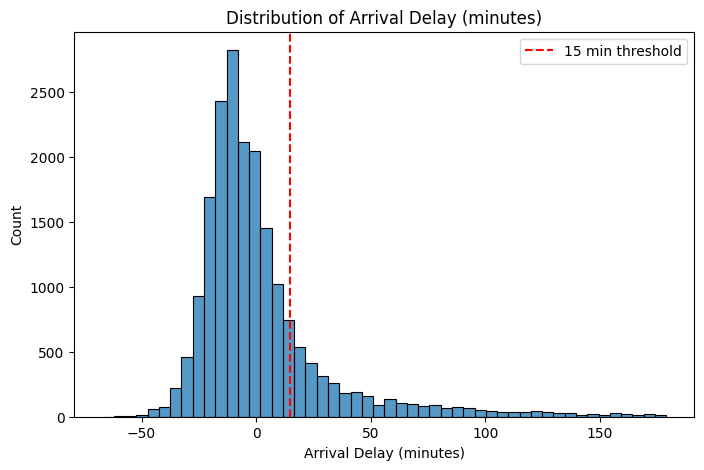

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['ARR_DELAY'] < 180]['ARR_DELAY'], bins=50)
plt.axvline(15, color='red', linestyle='--', label='15 min threshold')
plt.title('Distribution of Arrival Delay (minutes)')
plt.xlabel('Arrival Delay (minutes)')
plt.legend()
plt.show()

### Delays by Scheduled Departure Hour
Flights later in the day tend to accumulate delays from earlier legs of the same
aircraft's schedule — this is a well-known pattern in airline operations.

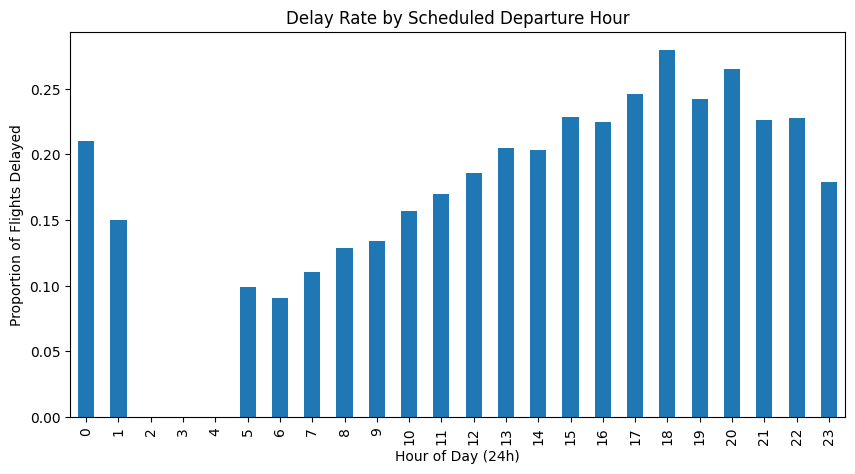

In [10]:
df['DEP_HOUR'] = (df['CRS_DEP_TIME'] // 100).astype(int)

hourly_delay_rate = df.groupby('DEP_HOUR')['DELAYED'].mean()

plt.figure(figsize=(10,5))
hourly_delay_rate.plot(kind='bar')
plt.title('Delay Rate by Scheduled Departure Hour')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Proportion of Flights Delayed')
plt.show()

### Delay Rate by Airline
Comparing carriers highlights operational differences — useful both as a feature
and as a sanity check that the data behaves as expected.

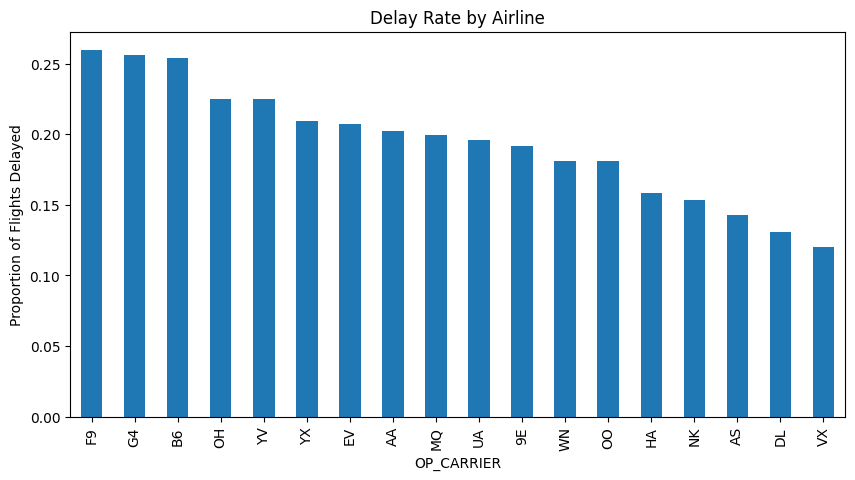

In [11]:
airline_delay_rate = df.groupby('OP_CARRIER')['DELAYED'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
airline_delay_rate.plot(kind='bar')
plt.title('Delay Rate by Airline')
plt.ylabel('Proportion of Flights Delayed')
plt.show()

## Feature Engineering

### Date-Based Features
We extract day-of-week and month from the flight date, since delay patterns
often differ by weekday vs weekend travel and by seasonal effects (e.g.
holiday-season congestion).

In [12]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek  # 0=Monday, 6=Sunday
df['MONTH'] = df['FL_DATE'].dt.month

### Encoding Categorical Features
`OP_CARRIER`, `ORIGIN`, and `DEST` are text columns and need to be converted
to numeric form for the model. Since `ORIGIN`/`DEST` contain hundreds of
distinct airports, one-hot encoding all of them would create an unmanageable
number of columns. We keep the most frequent categories and group the rest
into an "Other" bucket before encoding.

In [13]:
top_carriers = df['OP_CARRIER'].value_counts().nlargest(10).index
df['OP_CARRIER'] = df['OP_CARRIER'].where(df['OP_CARRIER'].isin(top_carriers), 'Other')

top_origins = df['ORIGIN'].value_counts().nlargest(20).index
df['ORIGIN'] = df['ORIGIN'].where(df['ORIGIN'].isin(top_origins), 'Other')

top_dests = df['DEST'].value_counts().nlargest(20).index
df['DEST'] = df['DEST'].where(df['DEST'].isin(top_dests), 'Other')

df_encoded = pd.get_dummies(df, columns=['OP_CARRIER', 'ORIGIN', 'DEST'], drop_first=True)

## Train/Test Split

We select our final feature set, dropping columns that either leak the
target (`ARR_DELAY`, `CANCELLED`, `DIVERTED`), are pure identifiers
(`FL_DATE`, `OP_CARRIER_FL_NUM`), or are redundant with an engineered
feature (`CRS_DEP_TIME`, replaced by `DEP_HOUR`).

We use `stratify=y` to preserve the same delayed/on-time class ratio
(~81% / 19%) in both the training and test sets, since our target
classes are imbalanced.

In [14]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in df_encoded.columns if c not in
                 ['FL_DATE', 'ARR_DELAY', 'CANCELLED', 'DIVERTED',
                  'DELAYED', 'OP_CARRIER_FL_NUM', 'CRS_DEP_TIME']]

X = df_encoded[feature_cols]
y = df_encoded['DELAYED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(15687, 54) (3922, 54)


### Feature Scaling
Logistic Regression is sensitive to feature scale — `DISTANCE` (values in
the thousands) dominates over binary dummy columns (0/1), causing slow,
unstable convergence. We standardize numeric features before fitting.

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = ['DISTANCE', 'DEP_HOUR', 'DAY_OF_WEEK', 'MONTH']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

## Baseline Model: Logistic Regression

We start with Logistic Regression as a simple, interpretable baseline before
trying more complex models. Since our classes are imbalanced (~81% on-time,
~19% delayed), we use `class_weight='balanced'` — without it, the model
could achieve 81% accuracy by simply predicting "not delayed" for every
flight, while being practically useless. This is why we look at precision,
recall, and the confusion matrix rather than accuracy alone.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)

y_pred = logreg.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.60      0.71      3187
           1       0.25      0.59      0.35       735

    accuracy                           0.59      3922
   macro avg       0.56      0.59      0.53      3922
weighted avg       0.75      0.59      0.64      3922

[[1901 1286]
 [ 303  432]]


## Random Forest Comparison
We compare against a Random Forest classifier, which can capture non-linear
relationships between features that Logistic Regression cannot. We use the
same `class_weight='balanced'` setting for the same imbalance reason. Random
Forest doesn't require feature scaling, so we use the original unscaled data.

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                              class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.64      0.73      3187
           1       0.26      0.57      0.36       735

    accuracy                           0.62      3922
   macro avg       0.56      0.60      0.55      3922
weighted avg       0.75      0.62      0.66      3922

[[2027 1160]
 [ 319  416]]


### Feature Importance
Random Forest gives us built-in feature importance — showing which factors
the model relies on most to predict a delay. This gives us explainability
without needing a separate library like SHAP.

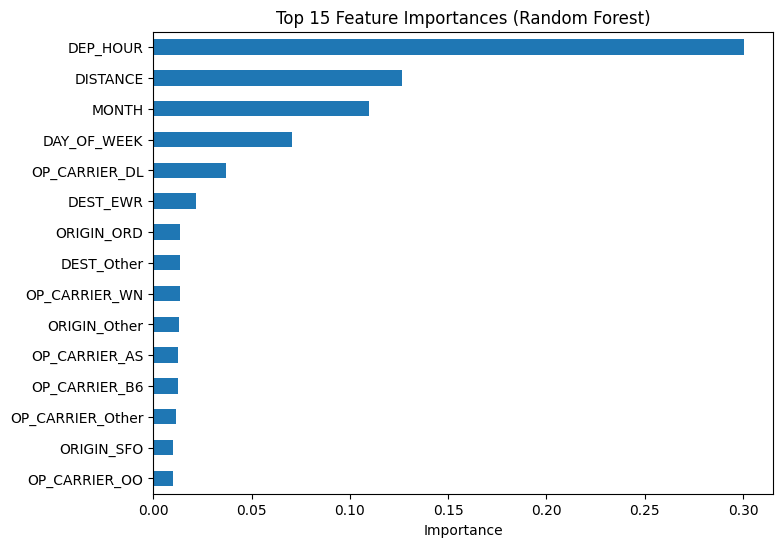

In [20]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.nlargest(15).plot(kind='barh', figsize=(8,6))
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

## Summary & Key Findings

- Built a binary classifier predicting flight delays (>15 min arrival delay)
  using 2018 US domestic flight data.
- Logistic Regression (interpretable baseline) achieved 59% recall on the
  delayed class; Random Forest achieved a comparable 57% recall with slightly
  better overall accuracy (62% vs 59%).
- The marginal improvement from Random Forest suggests the relationship
  between features and delay is largely linear — favoring the simpler, more
  interpretable model for this use case.
- **Scheduled departure hour** is by far the strongest predictor of delay,
  followed by distance, month, and day of week — evening flights show
  noticeably higher delay rates.

### Limitations & Future Work
- No weather data — in real-world delay prediction, weather is typically
  the single biggest driver, and its absence here is a known gap.
- Real-time features (e.g. upstream aircraft status, air traffic congestion)
  would likely improve recall substantially.
- With more time: hyperparameter tuning (GridSearchCV), and testing gradient
  boosting models (XGBoost/LightGBM).